Part 2: Discrete Quantum Information
Translate Part 1's continuous concepts into discrete circuit language

Part 1 explored the time-dependent and time-independent Schrödinger equation 
for a single particle in continuous space. This section reframes the same 
core ideas, superposition, probability, measurement, in the discrete language 
of quantum circuits, setting up the direct comparison developed in Part 3.

- qubit as truncated two-level system -> build a single-qubit circuit, show the state vector explicitly, connect to your harmonic oscillator's n=0, 1
- superposition -> apply hadamard, show the resulting state, conect to your wavepacket being a superposition of momentum components
- measurement statistics -> born rule, discrete vs continuous 
- entanglement -> two qubits, bell state

In [21]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
state = Statevector(qc)
print(state)

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [22]:
qc = QuantumCircuit(1)
qc.h(0)

state = Statevector(qc)
print(state)

# Verify normalisation: |alpha|^2 + |beta|^2 should equal 1
probs = state.probabilities()
print("Probabilities:", probs)
print("Sum:", sum(probs))

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Probabilities: [0.5 0.5]
Sum: 0.9999999999999998


Counts: {'1': 516, '0': 484}


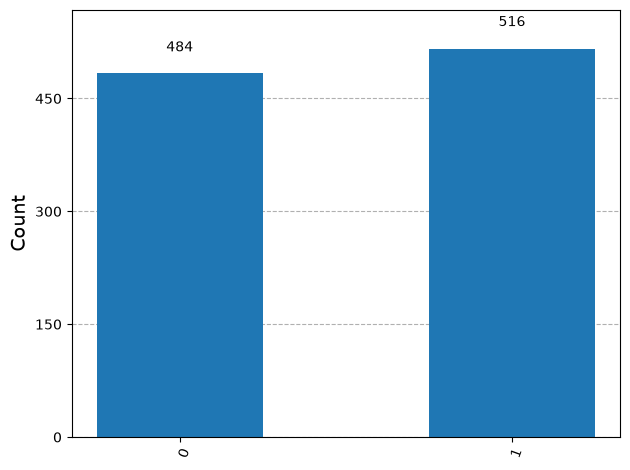

In [23]:
from qiskit_aer.primitives import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram

qc_measured = qc.copy()
qc_measured.measure_all()

sampler = Sampler()
job = sampler.run([qc_measured], shots=1000)
result = job.result()
counts = result[0].data.meas.get_counts()

print("Counts:", counts)
plot_histogram(counts)

Entanglement - Bell State

In [15]:
qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)

state_bell = Statevector(qc_bell)
print(state_bell)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [16]:
qc_bell_measured = qc_bell.copy()
qc_bell_measured.measure_all()

job = sampler.run([qc_bell_measured], shots=1000)
result = job.result()
counts = result[0].data.meas.get_counts()
print("Counts:", counts)

Counts: {'11': 511, '00': 489}


Unlike qubit states, superposition, and measurement (all direct discrete 
analogues of Part 1's single-particle wave mechanics), entanglement has 
no single-particle counterpart. It requires ≥2 subsystems whose joint 
state cannot be factored into independent single-particle states 
(proven explicitly for the Bell state: assuming separability leads to 
a direct algebraic contradiction). This is a genuine limitation of 
Part 1's scope, not an oversight, single-particle wavepacket dynamics 
simply cannot exhibit this phenomenon by construction.